# Changes from v1:
This notebook implements changes to issues found during the modeling process.

**Issue found:** Initial EDA found that the 'Month' column had an inbalance of sample size for different months, ranging from 184 sessions in February, versus May at 3364 sessions. This became evident as a problem when the February coefficient had the absolute highest value in my logistical regression model. Other months' coefficients were also near the top, which made me go back into the EDA and flag sample size as a potential issue.

**Fix:** This notebook is a copy of the v1 preprocessing notebook, but with a binning function applied to 'Month', to group low-session months together in an 'Other' category, and keep high session months as their own feature, with all other months becoming a baseline to compare against. The CSV gotten from this notebook will be compared against the old model to see how the coefficients have changed.

In [1]:
import pandas as pd
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

In [2]:
df = pd.read_csv('../data/online_shoppers_intention.csv')
df = df.drop(columns=['OperatingSystems', 'Browser', 'Region', 'Weekend'])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  str    
 11  TrafficType              12330 non-null  int64  
 12  VisitorType              12330 non-null  str    
 13  Revenue                  12330 non-null  bool   
dtypes: bool(1), float64(7), int64(4),

In [3]:
df.shape

(12330, 14)

In [4]:
df = df[~((df['Administrative'] + df['Informational'] + df['ProductRelated']) == 0)]
df.shape

(12324, 14)

In [5]:
df = df.sort_values('ProductRelated_Duration', ascending=False).reset_index(drop=True)
df.head(6)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,TrafficType,VisitorType,Revenue
0,5,3398.750000,6,2549.375000,449,63973.52223,0.000764,0.027701,0.000000,0.0,Dec,2,Returning_Visitor,False
1,17,2629.253968,24,2050.433333,705,43171.23338,0.004851,0.015431,0.763829,0.0,May,14,Returning_Visitor,False
2,15,2657.318056,13,1949.166667,343,29970.46597,0.005316,0.028971,0.000000,0.0,Dec,2,Returning_Visitor,False
3,20,1307.675000,3,132.666667,517,27009.85943,0.004385,0.014594,8.403164,0.0,Nov,2,Returning_Visitor,True
4,27,853.735949,2,126.500000,584,24844.15620,0.002099,0.009347,4.511100,0.0,Nov,8,Returning_Visitor,False
5,10,1251.200000,7,250.000000,414,23888.81000,0.009900,0.027062,1.033757,0.0,Sep,13,Returning_Visitor,False


In [6]:
# Drop Traffic Types with session counts less than 100, and one hot encode the rest
threshold = 100  # This threshold was kept even thought Month's new threshold is closer to 1000 because there are many more traffic types,
                 # and a threshold of 1000 would get rid of the granularity I'm looking for. I'm looking to capture differences in effect of more traffic varieties, and I'm doing this by keeping the threshold lower.
traffic_count= df['TrafficType'].value_counts()
len(traffic_count)


20

In [7]:
kept_traffic = traffic_count[traffic_count > threshold].index
len(kept_traffic)

11

In [8]:
kept_traffic

Index([2, 1, 3, 4, 13, 10, 6, 8, 5, 11, 20], dtype='int64', name='TrafficType')

In [9]:
type(kept_traffic)

pandas.Index

In [10]:
df['TrafficType'] = df['TrafficType'].where(df['TrafficType'].isin(kept_traffic), 'Other')
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,TrafficType,VisitorType,Revenue
0,5,3398.750000,6,2549.375000,449,63973.52223,0.000764,0.027701,0.000000,0.0,Dec,2,Returning_Visitor,False
1,17,2629.253968,24,2050.433333,705,43171.23338,0.004851,0.015431,0.763829,0.0,May,Other,Returning_Visitor,False
2,15,2657.318056,13,1949.166667,343,29970.46597,0.005316,0.028971,0.000000,0.0,Dec,2,Returning_Visitor,False
3,20,1307.675000,3,132.666667,517,27009.85943,0.004385,0.014594,8.403164,0.0,Nov,2,Returning_Visitor,True
4,27,853.735949,2,126.500000,584,24844.15620,0.002099,0.009347,4.511100,0.0,Nov,8,Returning_Visitor,False


In [11]:
df_encoded = pd.get_dummies(df, columns=['TrafficType'], drop_first=True)
print(df_encoded.columns)

Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month',
       'VisitorType', 'Revenue', 'TrafficType_2', 'TrafficType_3',
       'TrafficType_4', 'TrafficType_5', 'TrafficType_6', 'TrafficType_8',
       'TrafficType_10', 'TrafficType_11', 'TrafficType_13', 'TrafficType_20',
       'TrafficType_Other'],
      dtype='str')


The bool column for TrafficType 1 was dropped.

In [12]:
df_encoded.shape

(12324, 24)

In [13]:
df_encoded['Month'].unique()

<StringArray>
['Dec', 'May', 'Nov', 'Sep', 'Aug', 'Jul', 'June', 'Mar', 'Oct', 'Feb']
Length: 10, dtype: str

In [14]:
def month_to_bucket(m):
    if m in ['May', 'Nov', 'Mar', 'Dec']:
        return m
    else:
        return 'Other_Low_Volume'

df_encoded['Month_Bucket'] = df_encoded['Month'].apply(month_to_bucket)

In [15]:
month_dummies = pd.get_dummies(df_encoded['Month_Bucket'], prefix='Month')

month_dummies = month_dummies.drop(columns=['Month_Other_Low_Volume'])

df_encoded = pd.concat([df_encoded, month_dummies], axis=1)

df_encoded = df_encoded.drop(columns=['Month', 'Month_Bucket'])
df_encoded.info()

<class 'pandas.DataFrame'>
RangeIndex: 12324 entries, 0 to 12323
Data columns (total 27 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12324 non-null  int64  
 1   Administrative_Duration  12324 non-null  float64
 2   Informational            12324 non-null  int64  
 3   Informational_Duration   12324 non-null  float64
 4   ProductRelated           12324 non-null  int64  
 5   ProductRelated_Duration  12324 non-null  float64
 6   BounceRates              12324 non-null  float64
 7   ExitRates                12324 non-null  float64
 8   PageValues               12324 non-null  float64
 9   SpecialDay               12324 non-null  float64
 10  VisitorType              12324 non-null  str    
 11  Revenue                  12324 non-null  bool   
 12  TrafficType_2            12324 non-null  bool   
 13  TrafficType_3            12324 non-null  bool   
 14  TrafficType_4            12324 no

In [16]:
df_encoded.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,TrafficType_8,TrafficType_10,TrafficType_11,TrafficType_13,TrafficType_20,TrafficType_Other,Month_Dec,Month_Mar,Month_May,Month_Nov
0,5,3398.750000,6,2549.375000,449,63973.52223,0.000764,0.027701,0.000000,0.0,...,False,False,False,False,False,False,True,False,False,False
1,17,2629.253968,24,2050.433333,705,43171.23338,0.004851,0.015431,0.763829,0.0,...,False,False,False,False,False,True,False,False,True,False
2,15,2657.318056,13,1949.166667,343,29970.46597,0.005316,0.028971,0.000000,0.0,...,False,False,False,False,False,False,True,False,False,False
3,20,1307.675000,3,132.666667,517,27009.85943,0.004385,0.014594,8.403164,0.0,...,False,False,False,False,False,False,False,False,False,True
4,27,853.735949,2,126.500000,584,24844.15620,0.002099,0.009347,4.511100,0.0,...,True,False,False,False,False,False,False,False,False,True


The August month bool variable was dropped.

In [17]:
df_encoded.shape

(12324, 27)

In [18]:
df_encoded = pd.get_dummies(df_encoded, columns=['VisitorType'])
df_encoded = df_encoded.drop(columns=['VisitorType_Other']) # Drop a column after creating to keep New_Visitor for it's coefficient
print(df_encoded.columns)

Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Revenue',
       'TrafficType_2', 'TrafficType_3', 'TrafficType_4', 'TrafficType_5',
       'TrafficType_6', 'TrafficType_8', 'TrafficType_10', 'TrafficType_11',
       'TrafficType_13', 'TrafficType_20', 'TrafficType_Other', 'Month_Dec',
       'Month_Mar', 'Month_May', 'Month_Nov', 'VisitorType_New_Visitor',
       'VisitorType_Returning_Visitor'],
      dtype='str')


In [19]:
df_encoded['is_special_day'] = (df_encoded['SpecialDay'] > 0).astype(int)
df_encoded = df_encoded.drop(columns=['SpecialDay'])
df_encoded['is_special_day'].value_counts()

is_special_day
0    11073
1     1251
Name: count, dtype: int64

In [20]:
cols_skew_check = ['Administrative_Duration', 'Informational_Duration', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues']

for col in cols_skew_check:
    print(f'{col}:, {df_encoded[col].skew()}')

Administrative_Duration:, 5.614588744779994
Informational_Duration:, 7.577322285353236
ProductRelated_Duration:, 7.262734883763099
BounceRates:, 2.9575417003709106
ExitRates:, 2.153107889430193
PageValues:, 6.381432574576494


In [21]:
print("Skew Change")

for col in cols_skew_check:
    df_encoded[f'{col}_log'] = np.log1p(df_encoded[col])
    print(f'{col}_log:, {df_encoded[f'{col}_log'].skew()}')

Skew Change
Administrative_Duration_log:, 0.25443231124568577
Informational_Duration_log:, 1.9179162030007875
ProductRelated_Duration_log:, -1.4216896215061263
BounceRates_log:, 2.8866681177885525
ExitRates_log:, 2.0589449732176073
PageValues_log:, 1.8051523837119623


Administrative_Duration did well under a log transform.
Informational_Duration needs further inspection due to an insufficient decrease in skew (above 1).
ProductRelated_Duration went into a negative skew, likely due to the extreme outliers, which will likely need to be handled.
BounceRates and ExitRates showed a negligable change after log transform, and should be inspected.
PageValues decreased significantly, but needs to be further inspected (still above 1).

## Investigate Informational_Duration

In [22]:
(df_encoded['Informational_Duration'] == 0).mean()

np.float64(0.8048523206751055)

<Axes: >

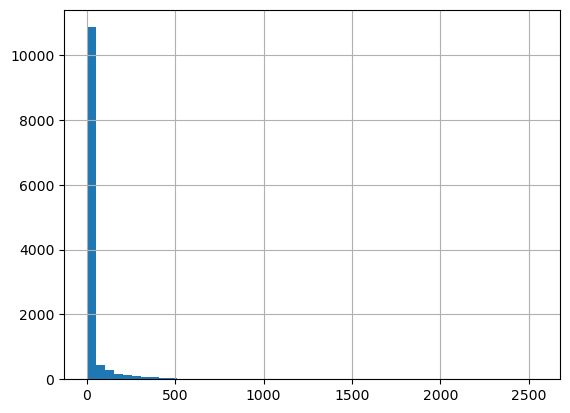

In [23]:
df_encoded['Informational_Duration'].hist(bins=50)

Informational_Duration has 0 values for 80% of the sessions, with which log transform did not sufficiently help.

Create an additional column to inform the model on whether informational pages were visited, keeping Informational_Duration_log to measure the effect of time.

In [24]:
df_encoded['Visited_Informational'] = (df_encoded['Informational_Duration'] > 0).astype(int)

## Investigate ProductRelated_Duration

In [25]:
df_encoded['ProductRelated_Duration'].describe()

count    12324.000000
mean      1195.327888
std       1913.953467
min          0.000000
25%        184.575000
50%        599.216667
75%       1464.701335
max      63973.522230
Name: ProductRelated_Duration, dtype: float64

Extreme outliers are affecting the impact of a log transform.

In [26]:
# Check where the extremes are
df_encoded['ProductRelated_Duration'].quantile([.9, .95, .99, .999])

0.900     2880.043333
0.950     4303.007629
0.990     8701.289370
0.999    17400.599610
Name: ProductRelated_Duration, dtype: float64

The duration approximately doubles as the quantile increases between the chosen values- there is no one extreme outlier to remove.

In [27]:
df_encoded['ProductRelated_Duration'].sort_values(ascending=False).head(10)

0    63973.52223
1    43171.23338
2    29970.46597
3    27009.85943
4    24844.15620
5    23888.81000
6    23342.08205
7    23050.10414
8    21857.04648
9    21672.24425
Name: ProductRelated_Duration, dtype: float64

In [28]:
# The originally log transformed duration
df_encoded['ProductRelated_Duration_log'].skew()

np.float64(-1.4216896215061263)

In [29]:
# Try capping to the value at the 99.9th quantile, minimizing the affect to only 0.1% of the data
cap_value = df_encoded['ProductRelated_Duration'].quantile(.999)
df_encoded['ProductRelated_Duration_caped'] = df_encoded['ProductRelated_Duration'].clip(upper=cap_value)
df_encoded['ProductRelated_Duration_caped_log'] = np.log1p(df_encoded['ProductRelated_Duration_caped'])
df_encoded['ProductRelated_Duration_caped_log'].skew()

np.float64(-1.4253118120191655)

In [30]:
cap_value = df_encoded['ProductRelated_Duration'].quantile(.99)
df_encoded['ProductRelated_Duration_caped'] = df_encoded['ProductRelated_Duration'].clip(upper=cap_value)
df_encoded['ProductRelated_Duration_caped_log'] = np.log1p(df_encoded['ProductRelated_Duration_caped'])
df_encoded['ProductRelated_Duration_caped_log'].skew()

np.float64(-1.442195981706158)

Capping before log transforming did not fix the skew, meaning the over correction during log transform isnt coming from the extreme outliers.

In [31]:
# Check the low end distribution instead
df_encoded['ProductRelated_Duration'].quantile([.01, .05, .10, .25])

0.01      0.000
0.05      0.000
0.10     36.000
0.25    184.575
Name: ProductRelated_Duration, dtype: float64

While the outliers reach ~64k seconds, 25% of the sessions have durations 184 or under, with 5% of sessions at 0.

In [32]:
(df_encoded['ProductRelated_Duration'] == 0).mean()

np.float64(0.06077572216812723)

<Axes: >

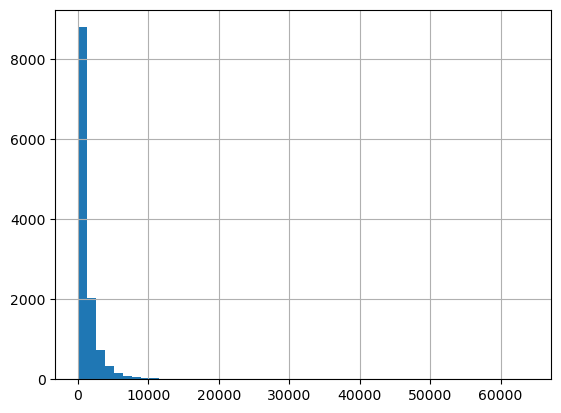

In [33]:
df_encoded['ProductRelated_Duration'].hist(bins=50)

In [34]:
# Try sqrt instead of log1p
df_encoded['ProductRelated_Duration_sqrt'] = np.sqrt(df_encoded['ProductRelated_Duration'])
print(df_encoded['ProductRelated_Duration_sqrt'].skew())

1.3947514763064568


The sqrt transormation more gently adjusted the feature's skew from approximately 7.26 to 1.39, instead of the log transformed skew, attempted with and without capping- resulting in an over corrected skew around -1.4.

<Axes: >

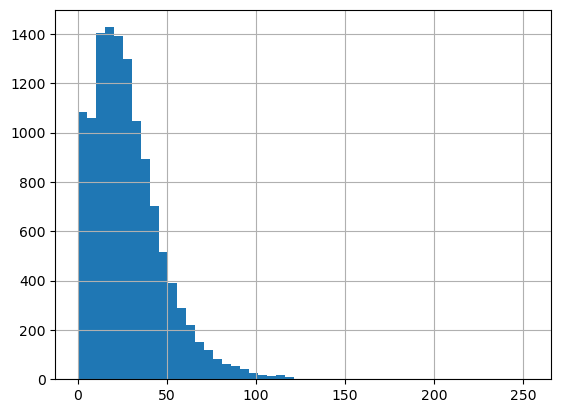

In [35]:
df_encoded['ProductRelated_Duration_sqrt'].hist(bins=50)

In [36]:
df_encoded.info()

<class 'pandas.DataFrame'>
RangeIndex: 12324 entries, 0 to 12323
Data columns (total 38 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Administrative                     12324 non-null  int64  
 1   Administrative_Duration            12324 non-null  float64
 2   Informational                      12324 non-null  int64  
 3   Informational_Duration             12324 non-null  float64
 4   ProductRelated                     12324 non-null  int64  
 5   ProductRelated_Duration            12324 non-null  float64
 6   BounceRates                        12324 non-null  float64
 7   ExitRates                          12324 non-null  float64
 8   PageValues                         12324 non-null  float64
 9   Revenue                            12324 non-null  bool   
 10  TrafficType_2                      12324 non-null  bool   
 11  TrafficType_3                      12324 non-null  bool   
 12  T

## Create Feature- Average Page Duration

In [37]:
(df_encoded['ProductRelated_Duration'] == 0).sum()

np.int64(749)

In [38]:
(df_encoded['ProductRelated'] == 0).sum()

np.int64(32)

In [39]:
impossible = df_encoded[(df_encoded['ProductRelated'] ==0) & df_encoded['ProductRelated_Duration'] != 0]
print(len(impossible))

0


In [40]:
df_encoded['avg_product_duration'] = np.where(
    df_encoded['ProductRelated'] > 0,
    df_encoded['ProductRelated_Duration'] / df_encoded['ProductRelated'],
    0
)

print('NaN Check:')
print(df_encoded['avg_product_duration'].isna().sum())

print('Inf Check:')
print(np.isinf(df_encoded['avg_product_duration']).sum())

df_encoded['avg_product_duration'].describe()

NaN Check:
0
Inf Check:
0


count    12324.000000
mean        37.652012
std         44.771109
min          0.000000
25%         17.653428
50%         28.890721
75%         45.090227
max       1411.000000
Name: avg_product_duration, dtype: float64

In [41]:
df_encoded['avg_product_duration'].skew()

np.float64(10.296891486741625)

In [42]:
df_encoded['avg_product_duration_sqrt'] = np.sqrt(df_encoded['avg_product_duration'])
print(df_encoded['avg_product_duration_sqrt'].skew())

1.3034527198762373


In [43]:
(df_encoded['Administrative_Duration'] == 0).sum()

np.int64(5897)

In [44]:
(df_encoded['Administrative'] == 0).sum()

np.int64(5762)

In [45]:
impossible = df_encoded[(df_encoded['Administrative'] ==0) & df_encoded['Administrative_Duration'] != 0]
print(len(impossible))

0


In [46]:
df_encoded['avg_administrative_duration'] = np.where(
    df_encoded['Administrative'] > 0,
    df_encoded['Administrative_Duration'] / df_encoded['Administrative'],
    0
)

print('NaN Check:')
print(df_encoded['avg_administrative_duration'].isna().sum())

print('Inf Check:')
print(np.isinf(df_encoded['avg_administrative_duration']).sum())

df_encoded['avg_administrative_duration'].describe()

NaN Check:
0
Inf Check:
0


count    12324.000000
mean        20.206114
std         46.004590
min          0.000000
25%          0.000000
50%          5.137500
75%         24.375000
max       1566.600000
Name: avg_administrative_duration, dtype: float64

In [47]:
df_encoded['avg_administrative_duration'].skew()

np.float64(9.422653184250608)

In [48]:
df_encoded['avg_administrative_duration_log'] = np.log1p(df_encoded['avg_administrative_duration'])
print(df_encoded['avg_administrative_duration_log'].skew())

0.2915144117142232


In [49]:
(df_encoded['Informational_Duration'] == 0).sum()

np.int64(9919)

In [50]:
(df_encoded['Informational'] == 0).sum()

np.int64(9693)

In [51]:
impossible = df_encoded[(df_encoded['Informational'] ==0) & df_encoded['Informational_Duration'] != 0]
print(len(impossible))

0


In [52]:
df_encoded['avg_informational_duration'] = np.where(
    df_encoded['Informational'] > 0,
    df_encoded['Informational_Duration'] / df_encoded['Informational'],
    0
)

print('NaN Check:')
print(df_encoded['avg_informational_duration'].isna().sum())

print('Inf Check:')
print(np.isinf(df_encoded['avg_informational_duration']).sum())

df_encoded['avg_informational_duration'].describe()

NaN Check:
0
Inf Check:
0


count    12324.000000
mean        14.814970
std         65.566454
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max       1778.000000
Name: avg_informational_duration, dtype: float64

In [53]:
df_encoded['avg_informational_duration'].skew()

np.float64(11.21572973322984)

In [54]:
df_encoded['avg_informational_duration_sqrt'] = np.sqrt(df_encoded['avg_informational_duration'])
print(df_encoded['avg_informational_duration_sqrt'].skew())

3.6019771818479382


A note post-preprocessing - I created the average duration page view features thinking that the lasso technique will help pick the best feature amongst raw page counts and durations, but realized that because the average was mathematically derived from page count and total durations, the features will be highly correlated, and lasso will not handle these redundant columns well. I end up having to pick the feature that is best correlated with revenue- which is still a useful step that lets me identify whether averages are better predictors that the raw scores.

In [55]:
# For each associate page type, rank each feature's correlation to Revenue
groups = {
    'Administrative': ['Administrative', 'Administrative_Duration_log', 'avg_administrative_duration_log'],
    'Informational': ['Informational', 'Informational_Duration_log', 'avg_informational_duration_sqrt'],
    'ProductRelated': ['ProductRelated', 'ProductRelated_Duration_sqrt', 'avg_product_duration_sqrt'],
}

for category, cols in groups.items():
    print(category)
    print(df_encoded[cols + ['Revenue']].corr()['Revenue'].drop('Revenue').sort_values(ascending=False))
    print()

Administrative
Administrative_Duration_log        0.166386
avg_administrative_duration_log    0.160742
Administrative                     0.138795
Name: Revenue, dtype: float64

Informational
Informational_Duration_log         0.112676
avg_informational_duration_sqrt    0.098061
Informational                      0.095126
Name: Revenue, dtype: float64

ProductRelated
ProductRelated_Duration_sqrt    0.205144
ProductRelated                  0.158416
avg_product_duration_sqrt       0.107439
Name: Revenue, dtype: float64



It turns out that average per-page durations are actually less correlated with Revenue than the total duration columns for each page type- which consistently ranks higher.

In [56]:
df_encoded = df_encoded.drop(columns=[
    'avg_administrative_duration_log',
    'avg_informational_duration_sqrt',
    'avg_product_duration_sqrt',
    'avg_informational_duration',
    'avg_administrative_duration',
    'avg_product_duration',
    'ProductRelated_Duration_caped', 
    'ProductRelated_Duration_caped_log', 
    'ProductRelated_Duration', 
    'ProductRelated_Duration_log', 
    'Administrative_Duration', 
    'Informational_Duration'
    ])
df_encoded.info()

<class 'pandas.DataFrame'>
RangeIndex: 12324 entries, 0 to 12323
Data columns (total 32 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Administrative                 12324 non-null  int64  
 1   Informational                  12324 non-null  int64  
 2   ProductRelated                 12324 non-null  int64  
 3   BounceRates                    12324 non-null  float64
 4   ExitRates                      12324 non-null  float64
 5   PageValues                     12324 non-null  float64
 6   Revenue                        12324 non-null  bool   
 7   TrafficType_2                  12324 non-null  bool   
 8   TrafficType_3                  12324 non-null  bool   
 9   TrafficType_4                  12324 non-null  bool   
 10  TrafficType_5                  12324 non-null  bool   
 11  TrafficType_6                  12324 non-null  bool   
 12  TrafficType_8                  12324 non-null  bool   
 1

## Investigate BounceRates

In [57]:
# Check unique values
df_encoded['BounceRates'].value_counts().sort_index()

BounceRates
0.000000    5518
0.000027       1
0.000034       1
0.000038       1
0.000039       1
            ... 
0.175000       1
0.176923       1
0.180000       4
0.183333       1
0.200000     695
Name: count, Length: 1872, dtype: int64

In [58]:
(df_encoded['BounceRates'] == 0).mean()

np.float64(0.4477442388834794)

44% of the sessions have bounce rates of 0- which means no compression happens for those rows at all. This is similar to how Informational_Duration was made of many 0 values (81%).

In [59]:
df_encoded['BounceRates'].nunique()

1872

There are still enough unique values in the column to not treat it as a categorical value.

In [60]:
# Create a column flagging the common 0 Bounce value for the model
df_encoded['has_bounce'] = (df_encoded['BounceRates'] > 0).astype(int)
df_encoded.info()

df_encoded = df_encoded.drop(columns=[
    'BounceRates_log'               # Leave the raw bounce rate, drop the log transformed column, as it did not decrease skew
    ])

df_encoded.info()

<class 'pandas.DataFrame'>
RangeIndex: 12324 entries, 0 to 12323
Data columns (total 33 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Administrative                 12324 non-null  int64  
 1   Informational                  12324 non-null  int64  
 2   ProductRelated                 12324 non-null  int64  
 3   BounceRates                    12324 non-null  float64
 4   ExitRates                      12324 non-null  float64
 5   PageValues                     12324 non-null  float64
 6   Revenue                        12324 non-null  bool   
 7   TrafficType_2                  12324 non-null  bool   
 8   TrafficType_3                  12324 non-null  bool   
 9   TrafficType_4                  12324 non-null  bool   
 10  TrafficType_5                  12324 non-null  bool   
 11  TrafficType_6                  12324 non-null  bool   
 12  TrafficType_8                  12324 non-null  bool   
 1

## Investigate ExitRates
Went from 2.15 -> 2.06 after log transform

In [61]:
(df_encoded['ExitRates'] == 0).mean()

np.float64(0.006166828951639078)

In [62]:
df_encoded['ExitRates'].nunique()

4776

<Axes: >

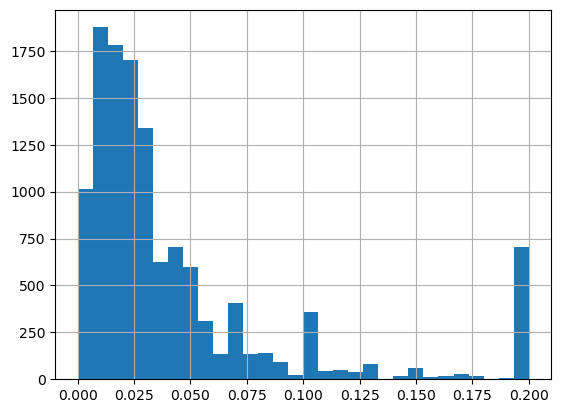

In [63]:
df_encoded['ExitRates'].hist(bins=30)

The seconds cluster near the end is what's causing the original skew.

In [64]:
# Check the characteristics of rows for the right-side peak
df_encoded[df_encoded['ExitRates'] > 0.18][['ExitRates', 'BounceRates', 'PageValues', 'ProductRelated', 'Administrative', 'Informational']].describe()

,ExitRates,BounceRates,PageValues,ProductRelated,Administrative,Informational
count,715.000000,715.000000,715.0,715.000000,715.000000,715.000000
mean,0.199809,0.196958,0.0,1.448951,0.020979,0.008392
std,0.001645,0.022298,0.0,1.281678,0.152869,0.091284
min,0.180342,0.000000,0.0,0.000000,0.000000,0.000000
25%,0.200000,0.200000,0.0,1.000000,0.000000,0.000000
50%,0.200000,0.200000,0.0,1.000000,0.000000,0.000000
75%,0.200000,0.200000,0.0,1.000000,0.000000,0.000000
max,0.200000,0.200000,0.0,13.000000,2.000000,1.000000


700 sessions,
At least 75% of ExitRates and BounceRates are 0.20,
All have PageValues of 0,
50% only visited 1 product page,
At least 75% visited 0 administrative pages and informational pages,

I conclude that .20 is a default bounce rate for sessions that showed low engagement, and very few total page views.

In [65]:
# Add a binary flag
df_encoded['high_exit_rate'] = (df_encoded['ExitRates'] >= 0.18).astype(int)
df_encoded = df_encoded.drop(columns=['ExitRates_log'])   # Drop the log transformed column created in the beginning
df_encoded.info()

<class 'pandas.DataFrame'>
RangeIndex: 12324 entries, 0 to 12323
Data columns (total 32 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Administrative                 12324 non-null  int64  
 1   Informational                  12324 non-null  int64  
 2   ProductRelated                 12324 non-null  int64  
 3   BounceRates                    12324 non-null  float64
 4   ExitRates                      12324 non-null  float64
 5   PageValues                     12324 non-null  float64
 6   Revenue                        12324 non-null  bool   
 7   TrafficType_2                  12324 non-null  bool   
 8   TrafficType_3                  12324 non-null  bool   
 9   TrafficType_4                  12324 non-null  bool   
 10  TrafficType_5                  12324 non-null  bool   
 11  TrafficType_6                  12324 non-null  bool   
 12  TrafficType_8                  12324 non-null  bool   
 1

## Investigate Page Values
Huge improvement from a skew of 6.38 to 1.80 after a log transform.

In [66]:
(df_encoded['PageValues'] == 0).mean()

np.float64(0.7784810126582279)

With 77% of sessions having PageValues of 0, a binary flag for 'has_page_value' would be valuable.
Keep the continuous, log transformed PageValue column to keep information on the other 23% of rows.

In [67]:
df_encoded['has_page_value'] = (df_encoded['PageValues'] > 0).astype(int)
df_encoded = df_encoded.drop(columns=['PageValues'])
df_encoded.info()

<class 'pandas.DataFrame'>
RangeIndex: 12324 entries, 0 to 12323
Data columns (total 32 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Administrative                 12324 non-null  int64  
 1   Informational                  12324 non-null  int64  
 2   ProductRelated                 12324 non-null  int64  
 3   BounceRates                    12324 non-null  float64
 4   ExitRates                      12324 non-null  float64
 5   Revenue                        12324 non-null  bool   
 6   TrafficType_2                  12324 non-null  bool   
 7   TrafficType_3                  12324 non-null  bool   
 8   TrafficType_4                  12324 non-null  bool   
 9   TrafficType_5                  12324 non-null  bool   
 10  TrafficType_6                  12324 non-null  bool   
 11  TrafficType_8                  12324 non-null  bool   
 12  TrafficType_10                 12324 non-null  bool   
 1

In [68]:
# Check redundancy from correlation across the whole feature set
X = df_encoded.drop(columns=['Revenue']).astype(float)
X_const = sm.add_constant(X)

vif = pd.DataFrame({
    'feature': X_const.columns,
    'VIF': [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]
}).sort_values('VIF', ascending=False)

vif = vif[vif['feature'] != 'const']
print(vif)

                          feature        VIF
22  VisitorType_Returning_Visitor  21.857979
21        VisitorType_New_Visitor  21.783752
4                     BounceRates  14.642573
25     Informational_Duration_log  12.111339
27          Visited_Informational   9.373713
31                 has_page_value   8.401505
5                       ExitRates   7.960761
26                 PageValues_log   7.758228
30                 high_exit_rate   6.637588
28   ProductRelated_Duration_sqrt   4.293042
3                  ProductRelated   3.481458
2                   Informational   3.271103
24    Administrative_Duration_log   2.958620
1                  Administrative   2.940946
19                      Month_May   2.163300
6                   TrafficType_2   2.043052
20                      Month_Nov   1.966972
29                     has_bounce   1.950322
18                      Month_Mar   1.711787
17                      Month_Dec   1.671487
7                   TrafficType_3   1.593410
8         

After one hot encoding and dropping the rare Other category, New_Visitor is about equal to 1 - Returning Visitor, because "Other" is a rare category with only 85 rows.

Returning visitors make up 10551 rows, and will be dropped, with new visitors and others showing change against the baseline being returning visitors.

In [69]:
df_encoded = df_encoded.drop(columns=['VisitorType_Returning_Visitor'])

In [70]:
X = df_encoded.drop(columns=['Revenue']).astype(float)
X_const = sm.add_constant(X)

vif = pd.DataFrame({
    'feature': X_const.columns,
    'VIF': [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]
}).sort_values('VIF', ascending=False)

vif = vif[vif['feature'] != 'const']
print(vif)

                         feature        VIF
4                    BounceRates  14.641937
24    Informational_Duration_log  12.111088
26         Visited_Informational   9.373319
30                has_page_value   8.398340
5                      ExitRates   7.959284
25                PageValues_log   7.754776
29                high_exit_rate   6.635654
27  ProductRelated_Duration_sqrt   4.292893
3                 ProductRelated   3.481329
2                  Informational   3.271102
23   Administrative_Duration_log   2.958425
1                 Administrative   2.940946
19                     Month_May   2.162978
6                  TrafficType_2   2.043049
20                     Month_Nov   1.964068
28                    has_bounce   1.945282
18                     Month_Mar   1.711367
17                     Month_Dec   1.651227
7                  TrafficType_3   1.593236
8                  TrafficType_4   1.513704
22                is_special_day   1.390703
21       VisitorType_New_Visitor

From my EDA notebook, I already know that BounceRates and ExitRates are highly correlated, and one of them needs to be dropped.

In [71]:
# Check correlations with Revenue to pick a feature to drop
df_encoded[['BounceRates', 'ExitRates', 'Revenue']].corr()['Revenue']

BounceRates   -0.150406
ExitRates     -0.206927
Revenue        1.000000
Name: Revenue, dtype: float64

In [72]:
df_encoded = df_encoded.drop(columns=['BounceRates'])

In [73]:
X = df_encoded.drop(columns=['Revenue']).astype(float)
X_const = sm.add_constant(X)

vif = pd.DataFrame({
    'feature': X_const.columns,
    'VIF': [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]
}).sort_values('VIF', ascending=False)

vif = vif[vif['feature'] != 'const']
print(vif)

                         feature        VIF
23    Informational_Duration_log  12.109979
25         Visited_Informational   9.373011
29                has_page_value   8.380021
24                PageValues_log   7.724353
4                      ExitRates   4.760944
26  ProductRelated_Duration_sqrt   4.291398
3                 ProductRelated   3.480065
2                  Informational   3.269180
28                high_exit_rate   3.159313
22   Administrative_Duration_log   2.948593
1                 Administrative   2.939179
18                     Month_May   2.162878
5                  TrafficType_2   2.042589
19                     Month_Nov   1.961491
17                     Month_Mar   1.710078
16                     Month_Dec   1.649161
6                  TrafficType_3   1.591607
27                    has_bounce   1.552429
7                  TrafficType_4   1.513595
21                is_special_day   1.390150
20       VisitorType_New_Visitor   1.329694
13                TrafficType_13

In [74]:
df_encoded[['Informational_Duration_log', 'Visited_Informational']].corr()

,Informational_Duration_log,Visited_Informational
Informational_Duration_log,1.000000,0.944333
Visited_Informational,0.944333,1.000000


These variables carry nearly the same information, since Visited_informational is derived from the duration itself (Informational_Duration_log > 0). 

In [75]:
df_encoded[['Informational_Duration_log', 'Visited_Informational', 'Revenue']].corr()['Revenue']

Informational_Duration_log    0.112676
Visited_Informational         0.109046
Revenue                       1.000000
Name: Revenue, dtype: float64

Nearly 80% of Informational_Duration was a value of 0, which is why the feature Visited_Informational was created. Since both of the columns' correlation with revenue is similar, and the binary of Visited_Informational is easily interpretable, I'll keep that column and drop the other.

In [76]:
df_encoded = df_encoded.drop(columns=['Informational_Duration_log'])

X = df_encoded.drop(columns=['Revenue']).astype(float)
X_const = sm.add_constant(X)

vif = pd.DataFrame({
    'feature': X_const.columns,
    'VIF': [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]
}).sort_values('VIF', ascending=False)

vif = vif[vif['feature'] != 'const']
print(vif)

                         feature       VIF
28                has_page_value  8.373735
23                PageValues_log  7.723263
4                      ExitRates  4.760363
25  ProductRelated_Duration_sqrt  4.286334
3                 ProductRelated  3.478457
27                high_exit_rate  3.159155
22   Administrative_Duration_log  2.948322
1                 Administrative  2.936842
2                  Informational  2.573714
24         Visited_Informational  2.551561
18                     Month_May  2.162782
5                  TrafficType_2  2.040977
19                     Month_Nov  1.961382
17                     Month_Mar  1.709069
16                     Month_Dec  1.649151
6                  TrafficType_3  1.591606
26                    has_bounce  1.552312
7                  TrafficType_4  1.513575
21                is_special_day  1.390122
20       VisitorType_New_Visitor  1.329605
13                TrafficType_13  1.281047
10                 TrafficType_8  1.210918
8          

In [77]:
df_encoded[['has_page_value', 'PageValues_log']].corr()

,has_page_value,PageValues_log
has_page_value,1.000000,0.923171
PageValues_log,0.923171,1.000000


In [78]:
df_encoded[['has_page_value', 'PageValues_log', 'Revenue']].corr()['Revenue']

has_page_value    0.602475
PageValues_log    0.635032
Revenue           1.000000
Name: Revenue, dtype: float64

In [79]:
# has_page_values is dropped due to a slightly lower correlation with Revenue, 
# and by itself does not do a better job than the original continuous value column it was derived from.
df_encoded = df_encoded.drop(columns=['has_page_value'])

In [80]:
X = df_encoded.drop(columns=['Revenue']).astype(float)
X_const = sm.add_constant(X)

vif = pd.DataFrame({
    'feature': X_const.columns,
    'VIF': [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]
}).sort_values('VIF', ascending=False)

vif = vif[vif['feature'] != 'const']
print(vif)

                         feature       VIF
4                      ExitRates  4.754046
25  ProductRelated_Duration_sqrt  4.272665
3                 ProductRelated  3.433312
27                high_exit_rate  3.158503
22   Administrative_Duration_log  2.948306
1                 Administrative  2.886846
2                  Informational  2.572687
24         Visited_Informational  2.550192
18                     Month_May  2.162767
5                  TrafficType_2  2.039453
19                     Month_Nov  1.956655
17                     Month_Mar  1.708385
16                     Month_Dec  1.646205
6                  TrafficType_3  1.590496
26                    has_bounce  1.551385
7                  TrafficType_4  1.513068
21                is_special_day  1.390116
20       VisitorType_New_Visitor  1.324905
13                TrafficType_13  1.280699
10                 TrafficType_8  1.210664
8                  TrafficType_5  1.196902
9                  TrafficType_6  1.182846
11         

The previous multicollinearity issue in the dataset has been drastically improved on.

In [81]:
df_encoded.info()

<class 'pandas.DataFrame'>
RangeIndex: 12324 entries, 0 to 12323
Data columns (total 28 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Administrative                12324 non-null  int64  
 1   Informational                 12324 non-null  int64  
 2   ProductRelated                12324 non-null  int64  
 3   ExitRates                     12324 non-null  float64
 4   Revenue                       12324 non-null  bool   
 5   TrafficType_2                 12324 non-null  bool   
 6   TrafficType_3                 12324 non-null  bool   
 7   TrafficType_4                 12324 non-null  bool   
 8   TrafficType_5                 12324 non-null  bool   
 9   TrafficType_6                 12324 non-null  bool   
 10  TrafficType_8                 12324 non-null  bool   
 11  TrafficType_10                12324 non-null  bool   
 12  TrafficType_11                12324 non-null  bool   
 13  TrafficType_

In [82]:
df_encoded.to_csv('../data/clean_online_shoppers_dataset_v2.csv', index=False)